In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from abc import ABC, abstractmethod

# --- 1. Сетка ---
class GridConfig:
    def __init__(self, x1, x2, t1, t2, nx, courant):
        self.x = np.linspace(x1, x2, nx)
        self.nx = nx
        self.dx = (x2 - x1) / (nx - 1)
        self.courant = courant
        self.c = 1.0
        self.dt = courant * self.dx / self.c
        self.t = np.arange(t1, t2 + self.dt, self.dt)
        self.nt = len(self.t)

# --- 2. Функции задачи ---
class WaveFunctions:
    def __init__(self, k=1, u0=None, v0=None, exact=None):
        self.k = k
        self.u0_func = u0 if u0 else lambda x: np.sin(k * np.pi * x)
        self.v0_func = v0 if v0 else lambda x: np.sin(k * np.pi * x)
        self.exact_func = exact if exact else self._exact_solution

    def initial_condition(self, x): return self.u0_func(x)
    def initial_speed(self, x): return self.v0_func(x)
    def _exact_solution(self, x, t):
        k = self.k
        return np.sin(k * np.pi * x) * (np.cos(k * np.pi * t) + (1 / np.pi) * np.sin(k * np.pi * t))
    def exact_solution(self, x, t): return self.exact_func(x, t)

# --- 3. Абстрактный базовый класс решателей ---
class BaseSolver(ABC):
    def __init__(self, grid: GridConfig, funcs: WaveFunctions):
        self.grid = grid
        self.funcs = funcs
    @abstractmethod
    def solve(self) -> np.ndarray: pass

# --- 4. Явный решатель ---
class ExplicitWaveSolver(BaseSolver):
    def solve(self) -> np.ndarray:
        nx, nt = self.grid.nx, self.grid.nt
        u = np.zeros((nt, nx))
        x = self.grid.x
        dt = self.grid.dt
        dx = self.grid.dx
        courant = self.grid.courant
        u[0, :] = self.funcs.initial_condition(x)
        u[1, 1:-1] = u[0, 1:-1] + dt * self.funcs.initial_speed(x[1:-1]) + \
            0.5 * (courant ** 2) * (u[0, 2:] - 2 * u[0, 1:-1] + u[0, :-2])
        u[1, 0] = u[1, -1] = 0.0
        for n in range(1, nt - 1):
            u[n + 1, 1:-1] = 2 * u[n, 1:-1] - u[n - 1, 1:-1] + \
                (courant ** 2) * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2])
            u[n + 1, 0] = u[n + 1, -1] = 0.0
        return u

# --- 5. Сервисы анализа ---
class ErrorCalculator:
    def __init__(self, funcs: WaveFunctions): self.funcs = funcs
    def max_absolute_error(self, u: np.ndarray, grid: GridConfig) -> np.ndarray:
        t_arr, x_arr = grid.t, grid.x
        nt = grid.nt
        errors = np.zeros(nt)
        for n in range(nt):
            exact = self.funcs.exact_solution(x_arr, t_arr[n])
            errors[n] = np.max(np.abs(u[n, :] - exact))
        return errors
    def max_relative_error(self, u: np.ndarray, grid: GridConfig) -> np.ndarray:
        t_arr, x_arr = grid.t, grid.x
        nt = grid.nt
        errors = np.zeros(nt)
        eps = 0
        for n in range(nt):
            exact = self.funcs.exact_solution(x_arr, t_arr[n])
            errors[n] = np.max(np.abs(u[n, 1:-1] - exact[1:-1]) / (np.abs(exact[1:-1]) + eps))
            # errors[n] = np.max((u[n, :] - exact) / ((exact) + eps))
        return errors

# --- 6. Сервис визуализации решения и ошибок ---
class SolutionPlotter:
    def plot_snapshots(self, grid: GridConfig, u: np.ndarray, funcs: WaveFunctions, time_indices=None, title="Snapshots"):
        if time_indices is None:
            time_indices = [0, grid.nt // 4, grid.nt // 2, 3 * grid.nt // 4, grid.nt - 1]
        plt.figure(figsize=(10, 6))
        for idx in time_indices:
            plt.plot(grid.x, u[idx, :], label=f'Num t={grid.t[idx]:.2f}')
            plt.plot(grid.x, funcs.exact_solution(grid.x, grid.t[idx]), '--', alpha=0.7)
        plt.xlabel('x')
        plt.ylabel('u(x,t)')
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_error(self, errors: np.ndarray, t_arr: np.ndarray, ylabel="Ошибка", title="Error vs Time"):
        plt.figure(figsize=(8, 4.5))
        plt.plot(t_arr, errors, 'r-', lw=2)
        plt.xlabel('Время t')
        plt.ylabel(ylabel)
        plt.yscale('log')
        plt.title(title)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_2d_map(self, grid: GridConfig, u: np.ndarray, title="2D карта: решение во времени и пространстве"):
        """
        Строит двумерную карту (heatmap) решения:
        X — пространство, Y — время, цвет — значение
        """
        plt.figure(figsize=(11, 7))
        plt.imshow(
            u, 
            extent=[grid.x[0], grid.x[-1], grid.t[0], grid.t[-1]],
            aspect='auto', origin='lower', cmap='RdBu_r'
        )
        plt.colorbar(label='u(x, t)')
        plt.xlabel('Координата x')
        plt.ylabel('Время t')
        plt.title(title)
        plt.tight_layout()
        plt.show()

# --- 7. Fourier-аниматор ---
class FourierAnimationService:
    def __init__(self):
        pass
    def animate_fft(self, u: np.ndarray, grid: GridConfig, gif_name='fft_evolution.gif', fps=20, kmax=None):
        nt, nx, dx = grid.nt, grid.nx, grid.dx
        k = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
        k = np.fft.fftshift(k)
        norm_factor = np.max(np.abs(np.fft.fft(u[0, :])))
        if kmax is not None:
            k_mask = (k >= -kmax) & (k <= kmax)
        else:
            k_mask = slice(None)
        fig, ax = plt.subplots(figsize=(10, 5))
        line, = ax.plot([], [], 'b-', lw=2)
        ax.set_xlim(k[k_mask][0], k[k_mask][-1])
        ax.set_ylim(0, 1.1)
        ax.set_xlabel('Волновое число k')
        ax.set_ylabel('Отн. амплитуда |FFT|')
        ax.set_title('Изменение спектра решения')
        def init():
            line.set_data([], [])
            return (line,)
        def animate(n):
            spectrum = np.fft.fft(u[n, :])
            spectrum = np.fft.fftshift(np.abs(spectrum) / norm_factor)
            line.set_data(k[k_mask], spectrum[k_mask])
            ax.set_title(f'FFT спектр, t={grid.t[n]:.3f}')
            return (line,)
        anim = animation.FuncAnimation(
            fig, animate, frames=nt, init_func=init, interval=40, blit=True
        )
        anim.save(gif_name, writer=animation.PillowWriter(fps=fps))
        plt.close(fig)
        print(f'Анимация FFT спектра сохранена: {gif_name}')

# --- 8. Главная функция вызова ---
def run_wave_demo():
    grid = GridConfig(x1=0, x2=1, t1=0, t2=0.7, nx=201, courant=1)
    funcs = WaveFunctions(k=1)
    solver = ExplicitWaveSolver(grid, funcs)
    u = solver.solve()

    # Анализ ошибок
    analyzer = ErrorCalculator(funcs)
    abs_errors = analyzer.max_absolute_error(u, grid)
    rel_errors = analyzer.max_relative_error(u, grid)

    # Визуализация
    plotter = SolutionPlotter()
    plotter.plot_snapshots(grid, u, funcs)
    plotter.plot_error(abs_errors, grid.t, ylabel="Максимальная абсолютная ошибка", title="Абсолютная ошибка во времени")
    plotter.plot_error(rel_errors, grid.t, ylabel="Максимальная относительная ошибка", title="Относительная ошибка во времени")
    plotter.plot_2d_map(grid, u, title="2D карта: решение волнового уравнения")

    # Анимация Фурье-спектра
    fourier_animator = FourierAnimationService()
    fourier_animator.animate_fft(u, grid, gif_name='fft_evolution.gif', fps=20, kmax=None)




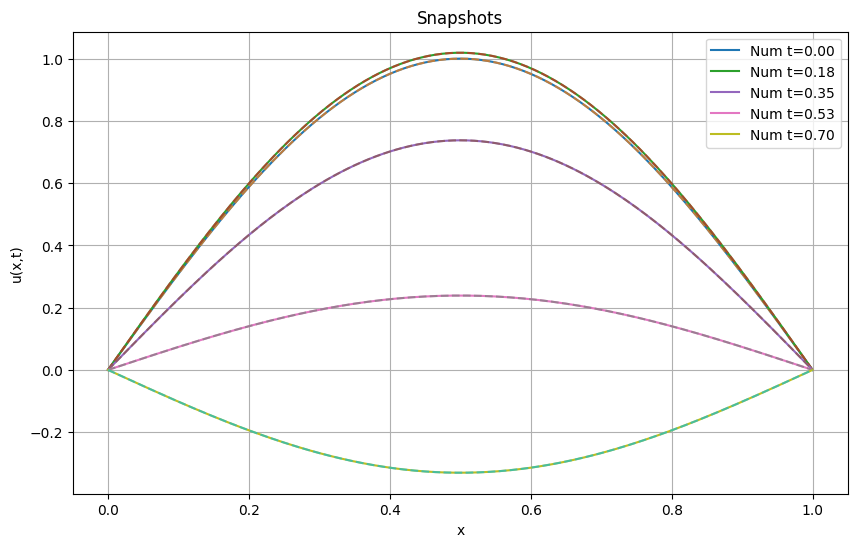

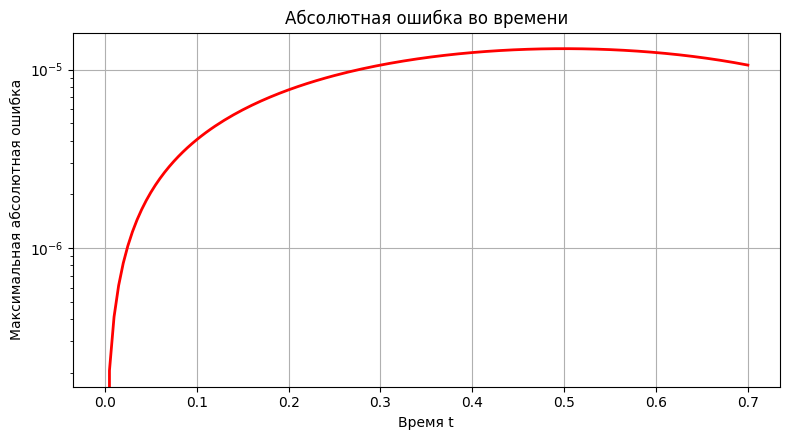

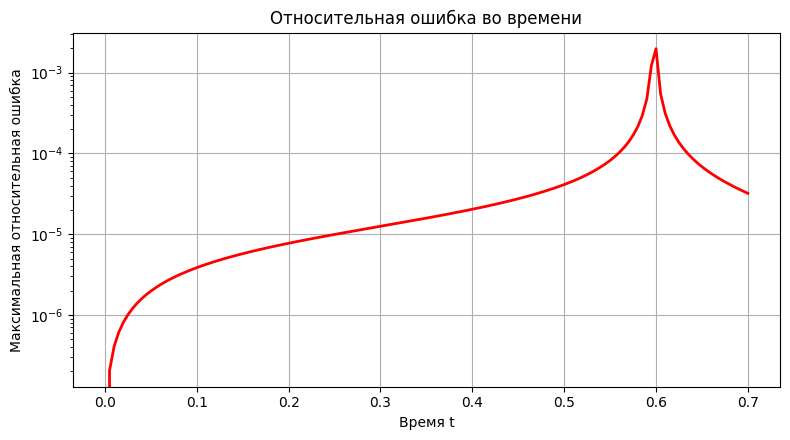

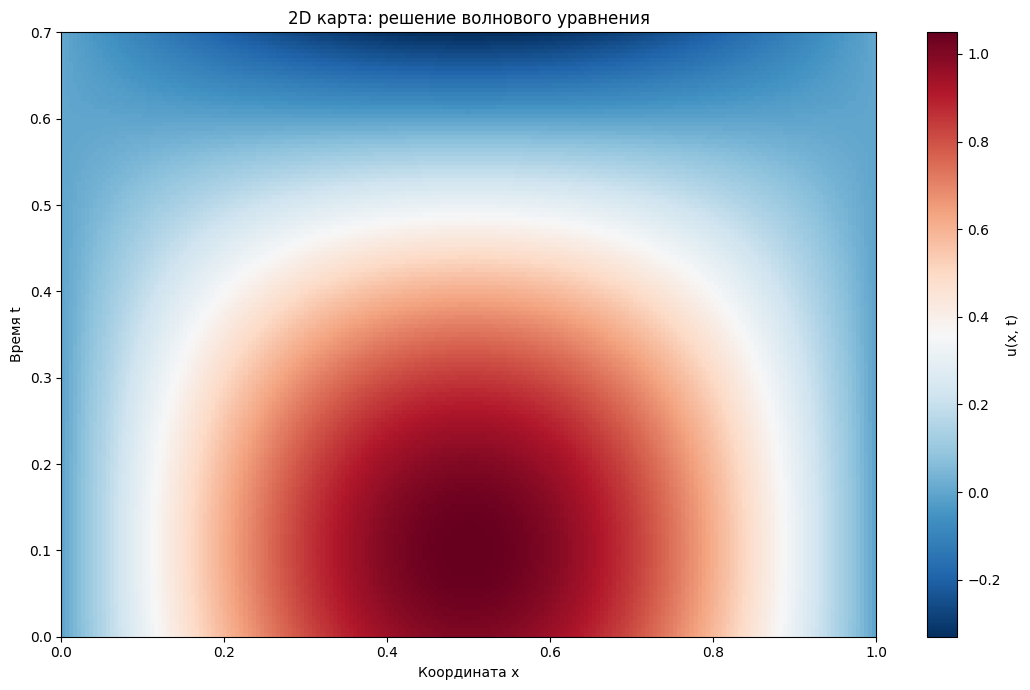

Анимация FFT спектра сохранена: fft_evolution.gif


In [4]:
if __name__ == "__main__":
    run_wave_demo()

#### Относительная ошибка при n = 201 и спасением знаменателя от нулевого решения

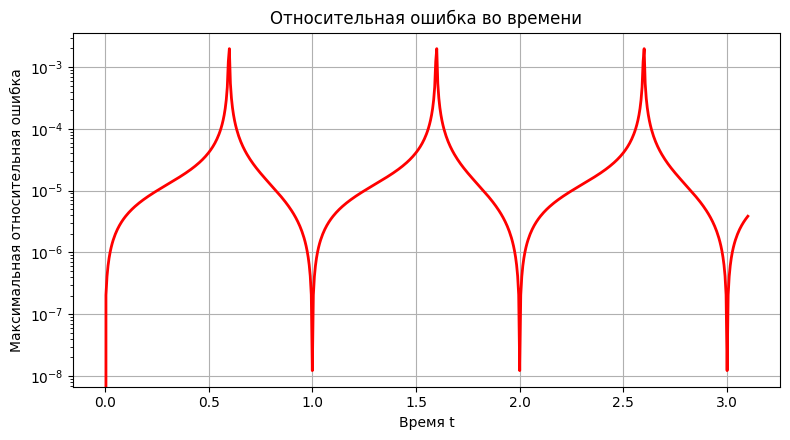

In [5]:
from numba import njit

In [26]:
@njit
def ahh(u,t):
    min1 = np.sum(np.abs(u[0]))
    
    for i in range(t):
        min = np.sum(np.abs(u[i]))
        if min <= min1:
            
            min1 = min
            t = i
    return t

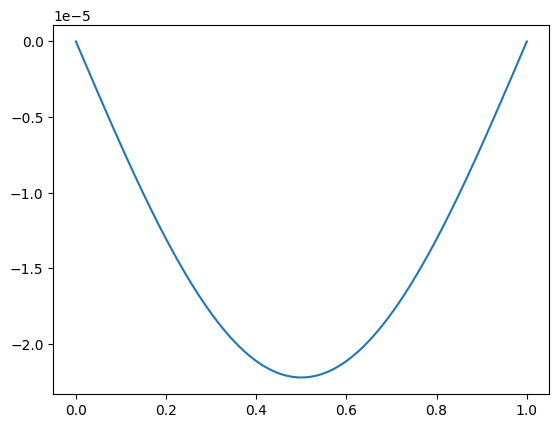

In [28]:
grid = GridConfig(x1=0, x2=1, t1=0, t2=0.7, nx=50001, courant=1)
funcs = WaveFunctions(k=1)
solver = ExplicitWaveSolver(grid, funcs)
u = solver.solve()
t = 0
u = np.array(u)
nt = u.shape[0]
t = ahh(u, nt)
plt.plot(grid.x,u[t])

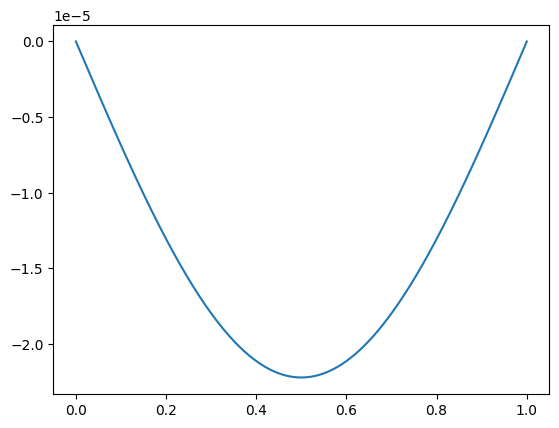